# Classical ML Baseline
Trajectory feature-based classification of particle types using standard non-linear models.
Used to assess whether hand-crafted features from xy coordinates are sufficient to separate the classes,
and to provide a performance baseline for the GNN.

In [2]:
import os
import subprocess

repo_root = subprocess.check_output(["git", "rev-parse", "--show-toplevel"]).decode().strip()
os.chdir(repo_root)

In [3]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)
from sklearn.decomposition import PCA

from trajan.data import TracksDataFrame

warnings.filterwarnings('ignore')
SEED = 42

## 1. Feature computation
Assumes `data` is a `TracksDataFrame` already loaded in the environment.

In [4]:
tracks_path = os.path.join("data", "cytoplasmic", "tracks.csv")

data = pd.read_csv(tracks_path, skiprows=1)
data = TracksDataFrame(data, frame_rate=10)

features_df = data.compute_features()
features_df.head()

,mean_speed,std_speed,alpha,diffusion_coeff,confinement_index,radius_of_gyration,max_displacement,net_displacement,confinement_ratio,pause_fraction,...,mean_local_alpha,std_local_alpha,range_local_alpha,non_gaussianity,kurtosis,turning_angle_entropy,asymmetry,set,label,type
0,0.026391,0.017055,1.033529,0.000027,0.140288,0.033946,0.101323,0.094589,0.100677,0.075843,...,1.033244,0.458958,2.374246,-0.096723,2.039245,2.026599,0.860246,0,0,endosome
1,0.020829,0.021207,1.041373,0.000012,0.099545,0.018768,0.056673,0.056392,0.129540,0.191388,...,0.737786,0.680921,3.406933,0.476346,2.485425,1.806935,0.957678,0,1,endosome
2,0.014044,0.012289,1.432160,0.000023,0.088002,0.010584,0.040860,0.040860,0.454596,0.000000,...,1.013507,0.376920,1.847353,-0.536512,3.982138,1.994643,0.983876,0,2,endosome
3,0.020907,0.014270,1.006503,0.000017,0.146338,0.011201,0.058874,0.021942,0.044851,0.021368,...,1.023223,0.438451,2.203159,-0.318917,2.691193,2.013310,0.677137,0,3,endosome
4,0.018722,0.013429,1.419735,0.000030,0.076282,0.013189,0.043729,0.042311,0.551204,0.024390,...,1.091519,0.374166,1.457496,-0.373570,3.202175,1.949865,0.979243,0,4,endosome


In [5]:
print(f"Total trajectories: {len(features_df)}")
print(f"\nClass distribution:")
print(features_df['type'].value_counts())
print(f"\nMissing values:")
print(features_df.isnull().sum())

Total trajectories: 573

Class distribution:
type
endosome     339
postgolgi    131
golgi        103
Name: count, dtype: int64

Missing values:
mean_speed                     0
std_speed                      0
alpha                          1
diffusion_coeff                1
confinement_index             29
radius_of_gyration             0
max_displacement               0
net_displacement               0
confinement_ratio              0
pause_fraction                 0
velocity_autocorr_lag1         0
vacf_decay                     0
straightness                   0
mean_turning_angle             0
std_turning_angle              0
directionality_ratio_short     0
directionality_ratio_mid       0
mean_local_alpha              48
std_local_alpha               48
range_local_alpha             48
non_gaussianity                0
kurtosis                       0
turning_angle_entropy          0
asymmetry                      0
set                            0
label                          

## 2. Feature exploration
Pairplot to visually assess class separability in feature space.

In [7]:
FEATURE_COLS = [
    # Diffusion
    'mean_speed', 'std_speed', 'alpha', 'diffusion_coeff', 'confinement_index',
    # Confinement
    'radius_of_gyration', 'max_displacement', 'net_displacement',
    'confinement_ratio', 'pause_fraction',
    # Directionality
    'velocity_autocorr_lag1', 'vacf_decay', 'straightness',
    'mean_turning_angle', 'std_turning_angle',
    'directionality_ratio_short', 'directionality_ratio_mid',
    # Local alpha
    'mean_local_alpha', 'std_local_alpha', 'range_local_alpha',
    # Statistical
    'non_gaussianity', 'kurtosis', 'turning_angle_entropy',
    # Asymmetry
    'asymmetry',
]

# Drop rows with NaN features (short trajectories)
features_clean = features_df.dropna(subset=FEATURE_COLS).copy()
print(f"Trajectories after dropping NaNs: {len(features_clean)} / {len(features_df)}")

Trajectories after dropping NaNs: 525 / 573


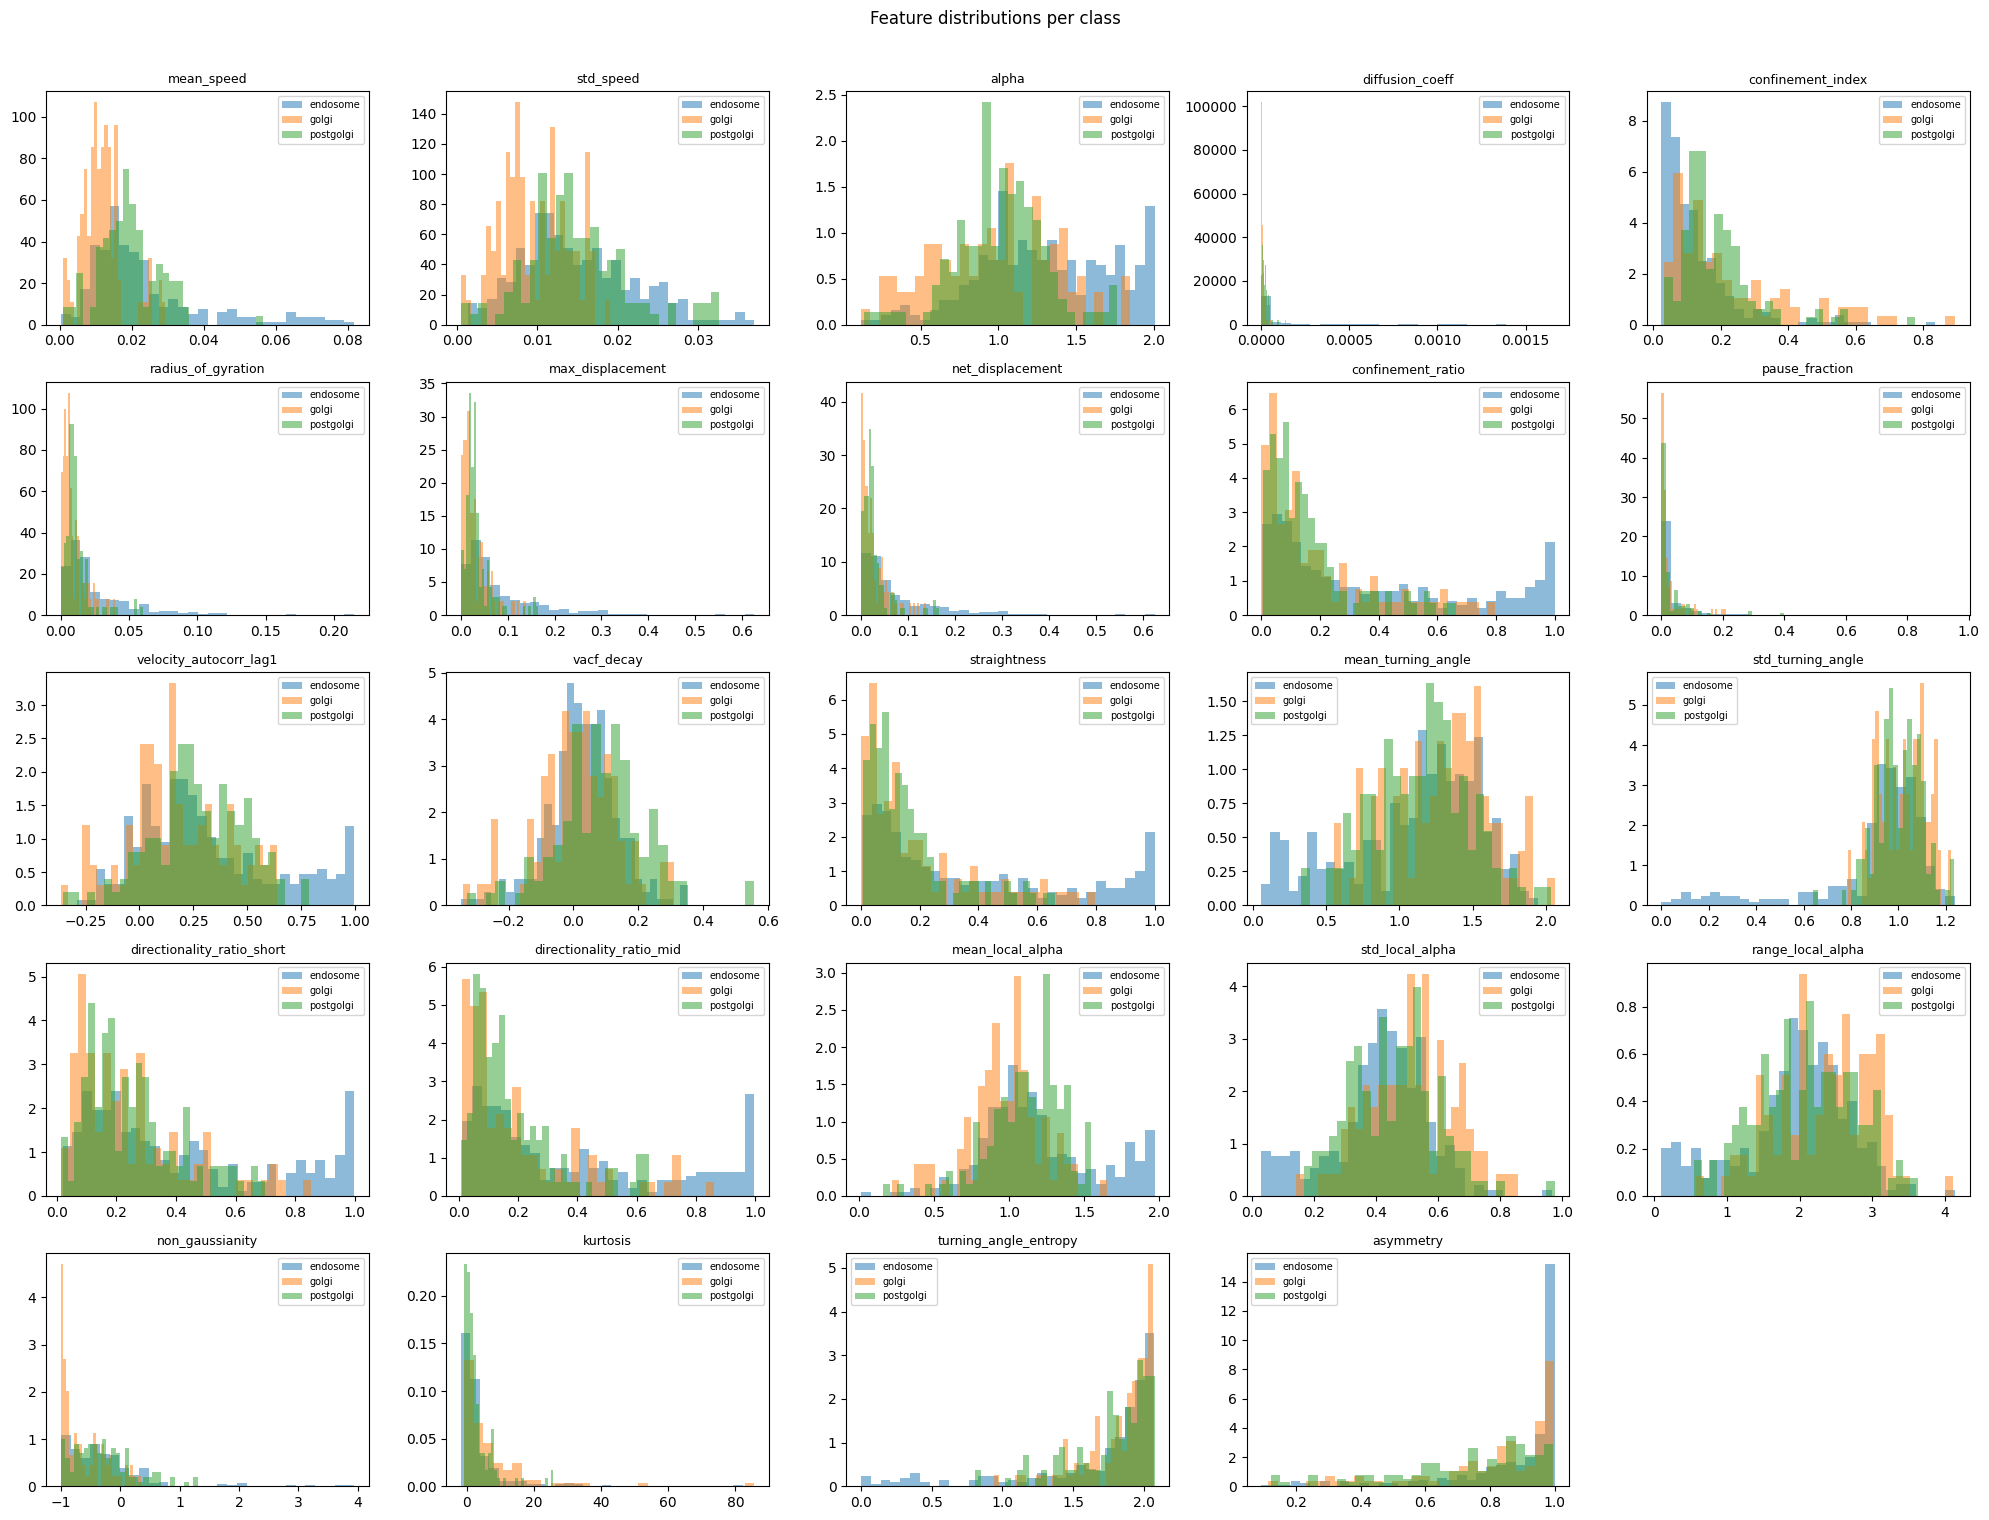

In [8]:
# Distribution of each feature per class
n_cols = 5
n_rows = int(np.ceil(len(FEATURE_COLS) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows * 3))
axes = axes.flatten()

for i, feat in enumerate(FEATURE_COLS):
    for particle_type in features_clean['type'].unique():
        vals = features_clean[features_clean['type'] == particle_type][feat].dropna()
        axes[i].hist(vals, bins=30, alpha=0.5, label=particle_type, density=True)
    axes[i].set_title(feat, fontsize=9)
    axes[i].legend(fontsize=7)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Feature distributions per class', y=1.01)
plt.tight_layout()
plt.show()

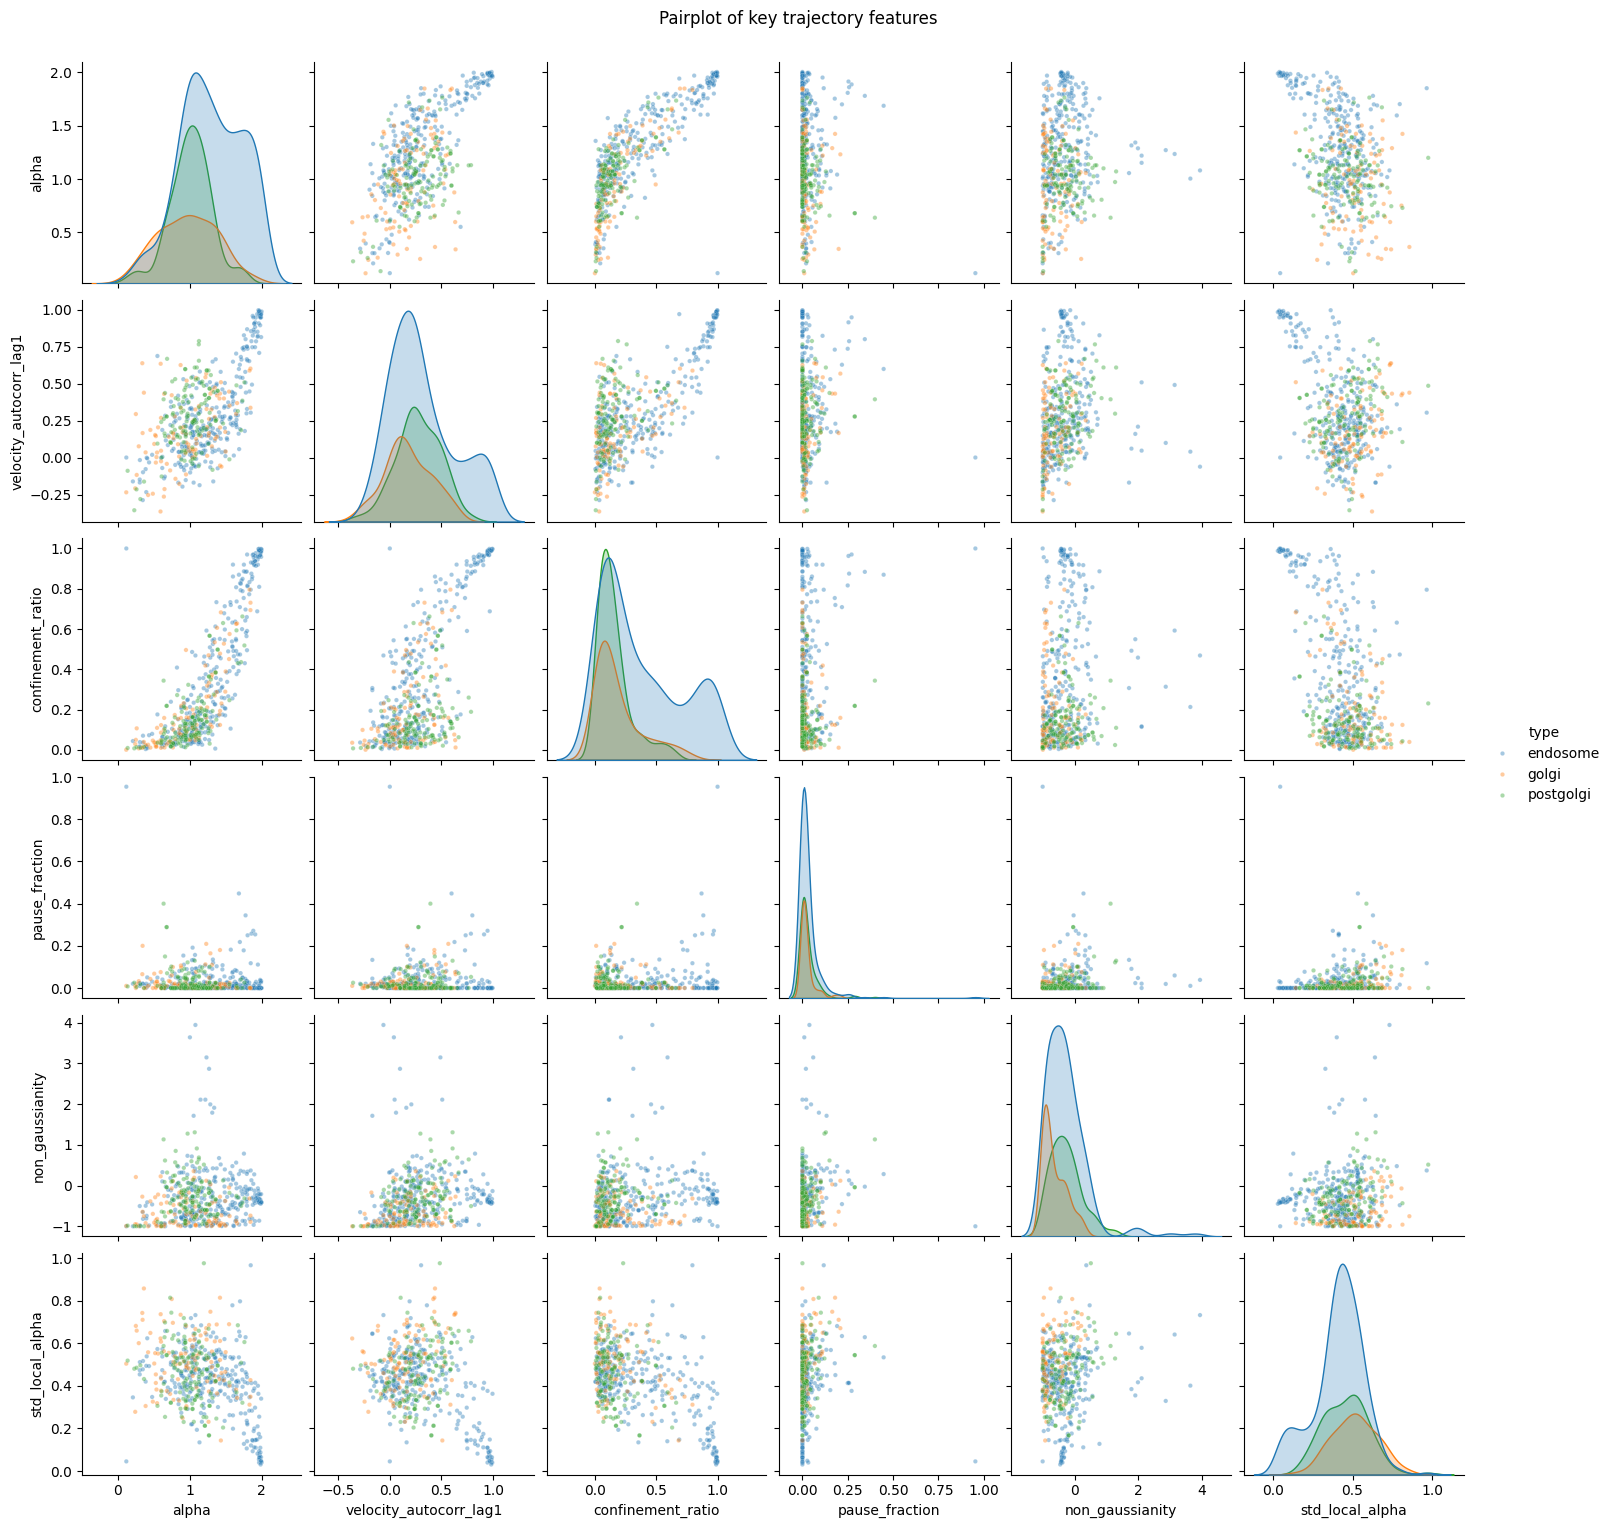

In [9]:
# Pairplot of the most discriminative features
key_features = [
    'alpha', 'velocity_autocorr_lag1', 'confinement_ratio',
    'pause_fraction', 'non_gaussianity', 'std_local_alpha', 'type'
]
sns.pairplot(features_clean[key_features].dropna(), hue='type', plot_kws={'alpha': 0.4, 's': 10})
plt.suptitle('Pairplot of key trajectory features', y=1.02)
plt.show()

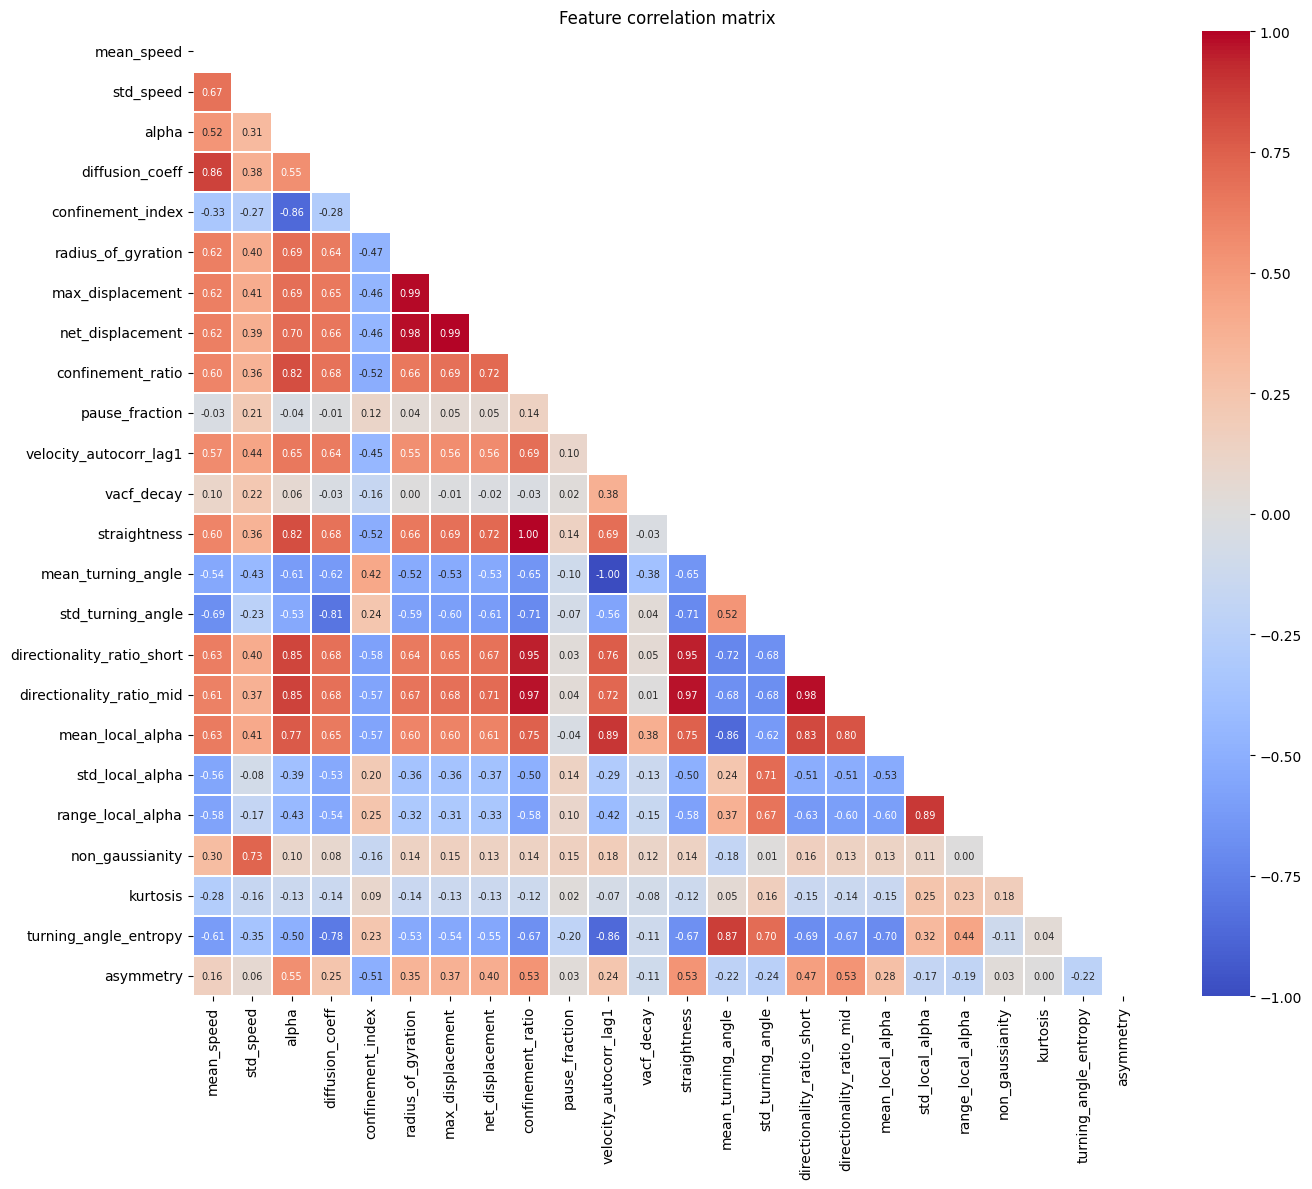

In [10]:
# Correlation heatmap — show only lower triangle to reduce visual noise
fig, ax = plt.subplots(figsize=(14, 12))
corr = features_clean[FEATURE_COLS].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
    ax=ax, vmin=-1, vmax=1, annot_kws={"size": 7}, linewidths=0.3,
)
ax.set_title('Feature correlation matrix')
plt.tight_layout()
plt.show()

## 3. PCA
Visualise class separability in a lower-dimensional feature space.

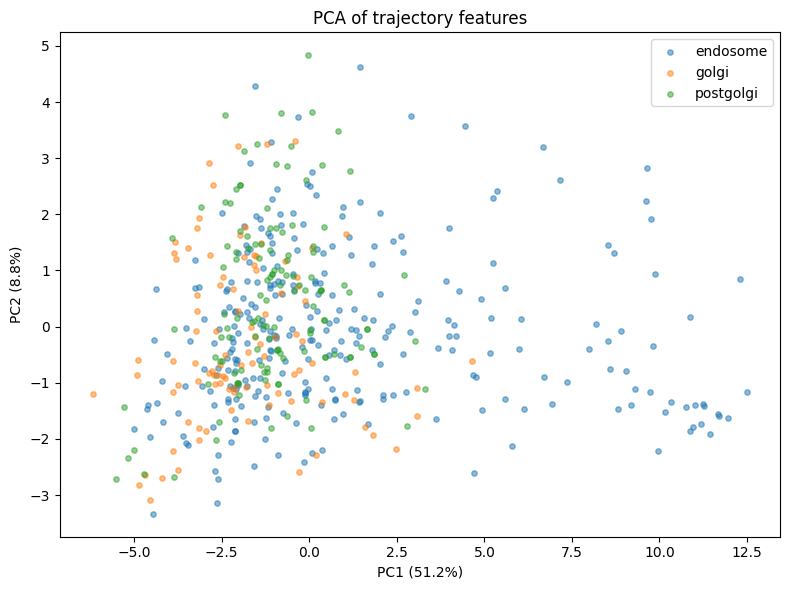

In [11]:
X = features_clean[FEATURE_COLS].values
y = features_clean['type'].values

le = LabelEncoder()
y_enc = le.fit_transform(y)
class_names = le.classes_

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2, random_state=SEED)
X_pca = pca.fit_transform(X_scaled)

fig, ax = plt.subplots(figsize=(8, 6))
for i, cls in enumerate(class_names):
    mask = y_enc == i
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1], label=cls, alpha=0.5, s=15)
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
ax.set_title('PCA of trajectory features')
ax.legend()
plt.tight_layout()
plt.show()

## 4. Train/test split
Recording-wise split, consistent with the GNN pipeline.

In [12]:
rng = np.random.default_rng(SEED)
test_recordings = []

for particle_type in features_clean['type'].unique():
    recordings = features_clean[features_clean['type'] == particle_type]['set'].unique()
    n_test = max(1, int(round(len(recordings) * 0.25)))
    test_recordings.extend(rng.choice(recordings, n_test, replace=False).tolist())

train_df = features_clean[~features_clean['set'].isin(test_recordings)]
test_df = features_clean[features_clean['set'].isin(test_recordings)]

X_train = train_df[FEATURE_COLS].values
y_train = le.transform(train_df['type'].values)
X_test = test_df[FEATURE_COLS].values
y_test = le.transform(test_df['type'].values)

print(f"Train: {len(X_train)} trajectories")
print(f"Test:  {len(X_test)} trajectories")
print(f"\nTrain class distribution: {dict(zip(class_names, np.bincount(y_train)))}")
print(f"Test class distribution:  {dict(zip(class_names, np.bincount(y_test)))}")

Train: 408 trajectories
Test:  117 trajectories

Train class distribution: {'endosome': 258, 'golgi': 58, 'postgolgi': 92}
Test class distribution:  {'endosome': 38, 'golgi': 41, 'postgolgi': 38}


## 5. Model training and cross-validation
All models use a StandardScaler inside a Pipeline to prevent data leakage.

In [13]:
models = {
    'Random Forest': RandomForestClassifier(
        n_estimators=200, class_weight='balanced', random_state=SEED, n_jobs=-1
    ),
    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=200, random_state=SEED
    ),
    'SVM (RBF)': SVC(
        kernel='rbf', class_weight='balanced', probability=True, random_state=SEED
    ),
    'KNN': KNeighborsClassifier(n_neighbors=10, n_jobs=-1),
}

pipelines = {
    name: Pipeline([('scaler', StandardScaler()), ('model', model)])
    for name, model in models.items()
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
cv_results = {}

for name, pipeline in pipelines.items():
    scores = cross_validate(
        pipeline, X_train, y_train, cv=cv,
        scoring=['accuracy', 'balanced_accuracy', 'f1_macro'],
        return_train_score=True,
    )
    cv_results[name] = scores
    print(f"{name}")
    print(f"  val accuracy:          {scores['test_accuracy'].mean():.3f} ± {scores['test_accuracy'].std():.3f}")
    print(f"  val balanced accuracy: {scores['test_balanced_accuracy'].mean():.3f} ± {scores['test_balanced_accuracy'].std():.3f}")
    print(f"  val macro F1:          {scores['test_f1_macro'].mean():.3f} ± {scores['test_f1_macro'].std():.3f}")
    print()

Random Forest
  val accuracy:          0.750 ± 0.026
  val balanced accuracy: 0.586 ± 0.049
  val macro F1:          0.601 ± 0.057

Gradient Boosting
  val accuracy:          0.696 ± 0.052
  val balanced accuracy: 0.553 ± 0.076
  val macro F1:          0.554 ± 0.089

SVM (RBF)
  val accuracy:          0.608 ± 0.039
  val balanced accuracy: 0.646 ± 0.017
  val macro F1:          0.570 ± 0.020

KNN
  val accuracy:          0.664 ± 0.034
  val balanced accuracy: 0.445 ± 0.035
  val macro F1:          0.441 ± 0.048



In [14]:
# Summary comparison
summary = pd.DataFrame({
    name: {
        'val_accuracy': scores['test_accuracy'].mean(),
        'val_balanced_accuracy': scores['test_balanced_accuracy'].mean(),
        'val_f1_macro': scores['test_f1_macro'].mean(),
        'train_accuracy': scores['train_accuracy'].mean(),
    }
    for name, scores in cv_results.items()
}).T.round(3)

summary

,val_accuracy,val_balanced_accuracy,val_f1_macro,train_accuracy
Random Forest,0.750,0.586,0.601,1.000
Gradient Boosting,0.696,0.553,0.554,1.000
SVM (RBF),0.608,0.646,0.570,0.679
KNN,0.664,0.445,0.441,0.744


## 6. Evaluation on held-out test set
Fit each pipeline on the full training set and evaluate on the test set.


Random Forest
              precision    recall  f1-score   support

    endosome       0.36      0.92      0.51        38
       golgi       0.50      0.10      0.16        41
   postgolgi       0.91      0.26      0.41        38

    accuracy                           0.42       117
   macro avg       0.59      0.43      0.36       117
weighted avg       0.59      0.42      0.36       117


Gradient Boosting
              precision    recall  f1-score   support

    endosome       0.38      0.89      0.54        38
       golgi       0.71      0.29      0.41        41
   postgolgi       0.73      0.21      0.33        38

    accuracy                           0.46       117
   macro avg       0.61      0.47      0.43       117
weighted avg       0.61      0.46      0.42       117


SVM (RBF)
              precision    recall  f1-score   support

    endosome       0.43      0.53      0.47        38
       golgi       0.52      0.61      0.56        41
   postgolgi       0.91      0

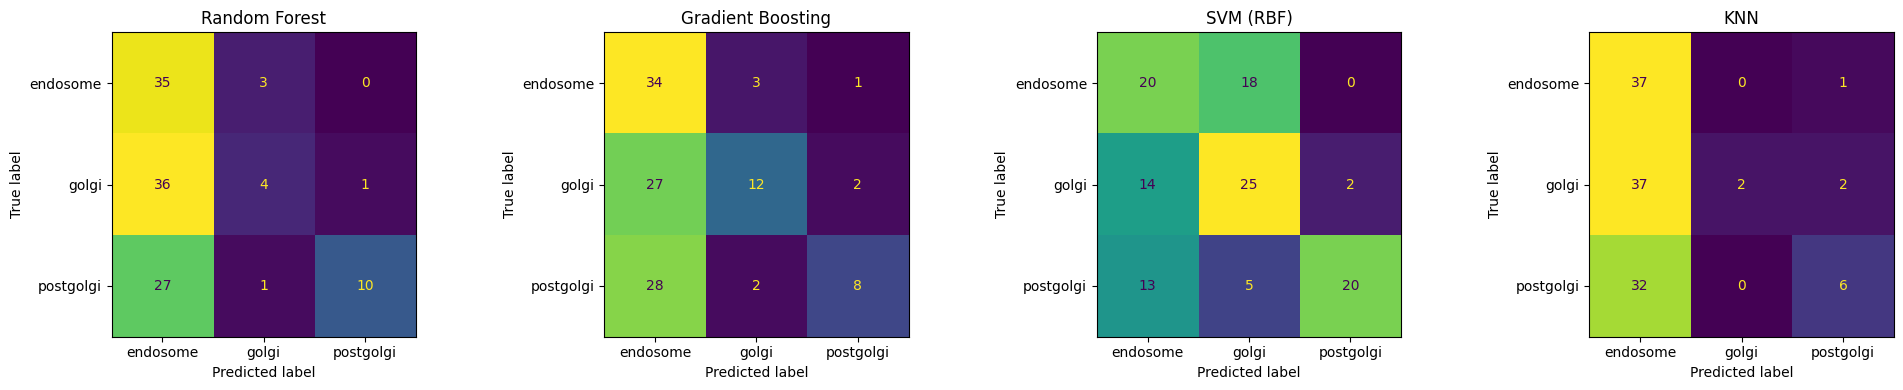

In [15]:
fig, axes = plt.subplots(1, len(pipelines), figsize=(5 * len(pipelines), 4))

for ax, (name, pipeline) in zip(axes, pipelines.items()):
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)

    print(f"\n{'='*40}")
    print(f"{name}")
    print('='*40)
    print(classification_report(y_test, y_pred, target_names=class_names))

    cm = confusion_matrix(y_test, y_pred)
    ConfusionMatrixDisplay(cm, display_labels=class_names).plot(ax=ax, colorbar=False)
    ax.set_title(name)

plt.tight_layout()
plt.show()

## 7. Feature importance (Random Forest)
Which features are most discriminative?

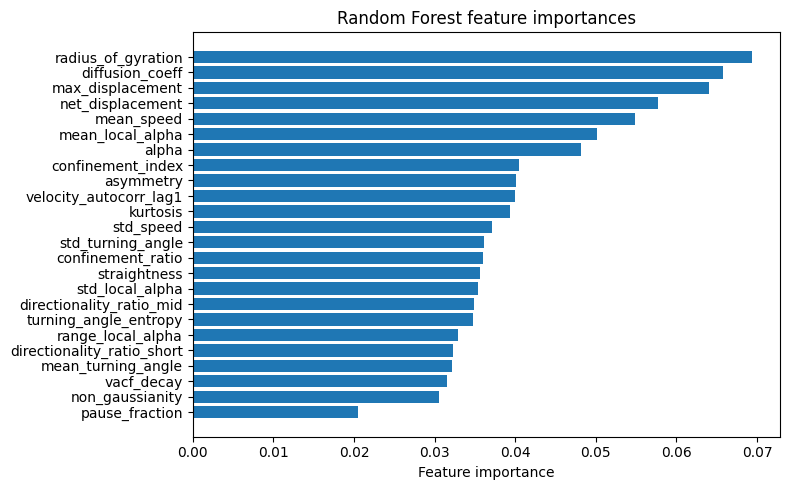

In [16]:
rf_pipeline = pipelines['Random Forest']
importances = rf_pipeline.named_steps['model'].feature_importances_
importance_df = pd.DataFrame({'feature': FEATURE_COLS, 'importance': importances})
importance_df = importance_df.sort_values('importance', ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(importance_df['feature'], importance_df['importance'])
ax.set_xlabel('Feature importance')
ax.set_title('Random Forest feature importances')
plt.tight_layout()
plt.show()

## 8. Separability assessment
Summary of what the classical baseline tells us about class separability.

In [17]:
best_model = summary['val_balanced_accuracy'].idxmax()
best_score = summary.loc[best_model, 'val_balanced_accuracy']

print(f"Best model: {best_model}")
print(f"Best cross-val balanced accuracy: {best_score:.3f}")
print()

if best_score < 0.5:
    print("Classes appear not separable from trajectory features alone.")
    print("Consider: additional features, longer trajectories, or spatial context.")
elif best_score < 0.7:
    print("Weak separability. GNN may improve over classical methods but gains may be limited.")
else:
    print("Classes are separable from trajectory features. GNN has room to improve further.")

Best model: SVM (RBF)
Best cross-val balanced accuracy: 0.646

Weak separability. GNN may improve over classical methods but gains may be limited.
